<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
tips_df=sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips_df.shape

(244, 7)

In [4]:
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
X=tips_df[['total_bill']]
y=tips_df['tip']
X.head()


,total_bill
0,16.99
1,10.34
2,21.01
3,23.68
4,24.59


In [6]:
y.head()

,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train.shape

(195, 1)

In [9]:
y_train.shape

(195,)

In [10]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
coefficient=model.coef_
interc=model.intercept_

In [12]:
y_pred=model.predict(X_test)
y_pred

array([3.04525623, 1.86330727, 3.55119456, 3.69452593, 2.31576375,
       2.83881627, 3.96728338, 2.26014262, 2.50615915, 2.57033737,
       2.88160176, 2.07723468, 2.06439904, 2.47407003, 2.00236009,
       2.91903905, 2.92652651, 3.23351235, 2.68478854, 5.33107064,
       3.13831465, 3.13403611, 2.4558862 , 1.94673896, 3.16077703,
       2.17564129, 2.02375283, 3.62927807, 2.68906708, 6.07767732,
       4.99734388, 1.75313465, 2.83025918, 3.09552917, 2.74040966,
       3.50092162, 2.21200895, 5.53644096, 2.33287794, 3.35010279,
       2.04942412, 2.47834858, 3.48701634, 2.03017065, 2.03124029,
       1.25361414, 2.05798121, 2.92438724, 1.73388118])

In [13]:
comparison=pd.DataFrame({
    'actual_tip': y_test,
   'predicted_tip':y_pred,
})

In [14]:
comparison

,actual_tip,predicted_tip
24,3.18,3.045256
6,2.00,1.863307
153,2.00,3.551195
211,5.16,3.694526
198,2.00,2.315764
176,2.00,2.838816
192,2.56,3.967283
124,2.52,2.260143
9,3.23,2.506159
101,3.00,2.570337


In [15]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
print(mse)
mae=mean_absolute_error(y_test,y_pred)
print(mae)

0.5688142529229536
0.6208580000398983


In [16]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(r2)

0.5449381659234664


In [17]:
import pickle
with open("model.pkl",'wb') as f:
  pickle.dump(model,f)

print('Model saved')

Model saved


In [18]:
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

pred = loaded_model.predict(X_test)
pred

array([3.04525623, 1.86330727, 3.55119456, 3.69452593, 2.31576375,
       2.83881627, 3.96728338, 2.26014262, 2.50615915, 2.57033737,
       2.88160176, 2.07723468, 2.06439904, 2.47407003, 2.00236009,
       2.91903905, 2.92652651, 3.23351235, 2.68478854, 5.33107064,
       3.13831465, 3.13403611, 2.4558862 , 1.94673896, 3.16077703,
       2.17564129, 2.02375283, 3.62927807, 2.68906708, 6.07767732,
       4.99734388, 1.75313465, 2.83025918, 3.09552917, 2.74040966,
       3.50092162, 2.21200895, 5.53644096, 2.33287794, 3.35010279,
       2.04942412, 2.47834858, 3.48701634, 2.03017065, 2.03124029,
       1.25361414, 2.05798121, 2.92438724, 1.73388118])

In [19]:
import matplotlib.pyplot as plt


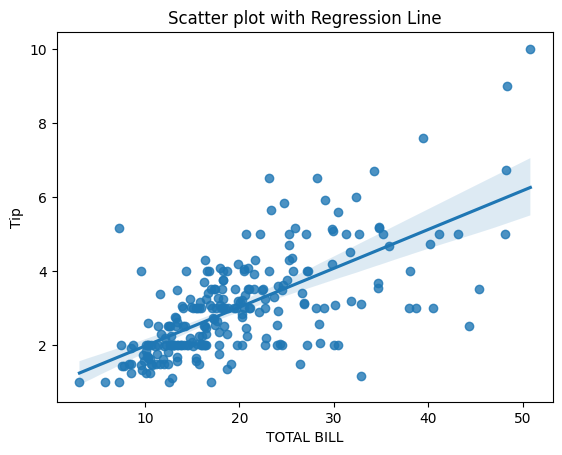

In [23]:
sns.regplot(x="total_bill",y="tip",data=tips_df)
plt.xlabel('TOTAL BILL')
plt.ylabel('Tip')
plt.title("Scatter plot with Regression Line")
plt.show()

In [24]:
from sklearn.datasets import  fetch_california_housing
housing=fetch_california_housing

In [26]:
housing

<function sklearn.datasets._california_housing.fetch_california_housing(*, data_home=None, download_if_missing=True, return_X_y=False, as_frame=False, n_retries=3, delay=1.0)>

In [27]:
X,y=fetch_california_housing(return_X_y=True)

In [29]:
X.shape

(20640, 8)

In [30]:
y.shape

(20640,)

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=44)

In [33]:
y_train

array([1.797, 1.013, 1.727, ..., 3.842, 2.229, 1.225])

In [34]:
X_train.shape

(16512, 8)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [42]:
from sklearn.linear_model import Lasso
model_lasso=Lasso()

In [43]:
model_lasso.fit(X_train_scaled,y_train)

Lasso()

In [61]:
model_lasso.coef_

array([ 0.,  0.,  0., -0., -0., -0., -0., -0.])

In [47]:
from sklearn.linear_model import Ridge
model_ridge=Ridge()

In [49]:
model_ridge.fit(X_train_scaled,y_train)

Ridge()

In [44]:
from sklearn.linear_model import ElasticNet
model_elastic_net=ElasticNet()

In [52]:
model_elastic_net.fit(X_train_scaled,y_train)

ElasticNet()

In [53]:
y_pred=model.predict(X_test_scaled)
print(y_pred)

[2.55823281 3.35684836 4.09751962 ... 2.80867915 2.38870762 1.61280809]


In [55]:
y_pred_Lasso=model_lasso.predict(X_test_scaled)

In [56]:
print(y_pred_Lasso)

[2.0677633 2.0677633 2.0677633 ... 2.0677633 2.0677633 2.0677633]


In [57]:
y_pred_ridge=model_ridge.predict(X_test_scaled)


In [58]:
print(y_pred_ridge)

[2.55805966 3.35658646 4.0975895  ... 2.80868816 2.38863631 1.61282596]


In [59]:
y_pred_elastic_net=model_elastic_net.predict(X_test_scaled)

In [60]:
print(y_pred_elastic_net)

[2.12337531 2.30497493 2.70887472 ... 2.33256835 2.145401   1.88978646]


In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(mean_squared_error(y_test, y_pred))

0.5347838950335047


In [63]:
mean_absolute_error(y_test, y_pred)

0.5278504031670417

In [64]:
r2_score(y_test, y_pred)

0.6084415600235556

In [65]:
mean_squared_error(y_test, y_pred_Lasso)

1.3657988826860425

In [66]:
r2_score(y_test, y_pred_Lasso)

-1.156503153976196e-05

In [67]:
# linear regression
print(mean_squared_error(y_test, y_pred))

0.5347838950335047


In [68]:
# lasso regression
print(mean_squared_error(y_test, y_pred_Lasso))

1.3657988826860425


In [70]:
# ridge regression
print(mean_squared_error(y_test, y_pred_ridge))

0.5347633787931915


In [71]:
# elastic net regression
print(mean_squared_error(y_test, y_pred_elastic_net))

1.092171083664887
